# **Import Libraries**

In [34]:
import joblib
from pathlib import Path
import sys
from typing import Any, Literal
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings("ignore")

# set project root directory
PROJECT_ROOT = Path().resolve().parent
# add project root to sys.path
sys.path.insert(0, str(PROJECT_ROOT))

# **Deserialize saved best model**

In [35]:
# define function to deserialize object
def deserialize_object(path: str) -> Any:
    """
    Deserialize the object into specified path.

    Parameters:
    -----------
    path (str) : The path to deserialize the object.

    Returns:
    --------
    object (Any) : Any object will be deserialized.
    """

    obj = joblib.load(path)
    return obj


In [36]:
# deserialize X_train
X_train = deserialize_object(f"{PROJECT_ROOT}/data/processed/X_train.pkl")

In [37]:
# load saved best model
best_model = deserialize_object(f"{PROJECT_ROOT}/model/best_model.pkl")
best_model

,steps,"[('preprocessing', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. Th

# **Interpret Model**

## **Feature Importances**

In [38]:
best_model.named_steps['model'].feature_importances_

array([ 0.30140119,  1.31619239,  0.63216135,  0.01578902,  1.58389357,
        1.68194743,  1.17150764,  0.14302782,  3.16568272,  0.08288404,
        0.3116097 ,  0.07316342,  0.50015081,  0.22007058,  0.70203336,
        0.05964862,  0.07598094,  0.56470791,  5.37811853,  0.1608688 ,
        0.        ,  7.11296494,  0.19622402,  0.4620131 ,  0.23675632,
        0.67116348,  0.7509909 ,  1.41887055,  0.24655034,  3.11278451,
        7.32295778, 13.45066141, 11.29673628,  1.12880326,  0.16022081,
        0.50305339,  0.86085071,  0.17968396,  0.90070552,  6.40869654,
        1.28021805,  1.43284396,  0.16420701,  0.81631244,  0.03179279,
        0.04867808,  0.3862384 , 11.631677  ,  3.23528226,  0.03953645,
        0.24179218,  3.26543412,  1.58702592,  0.20779265,  1.06964102])

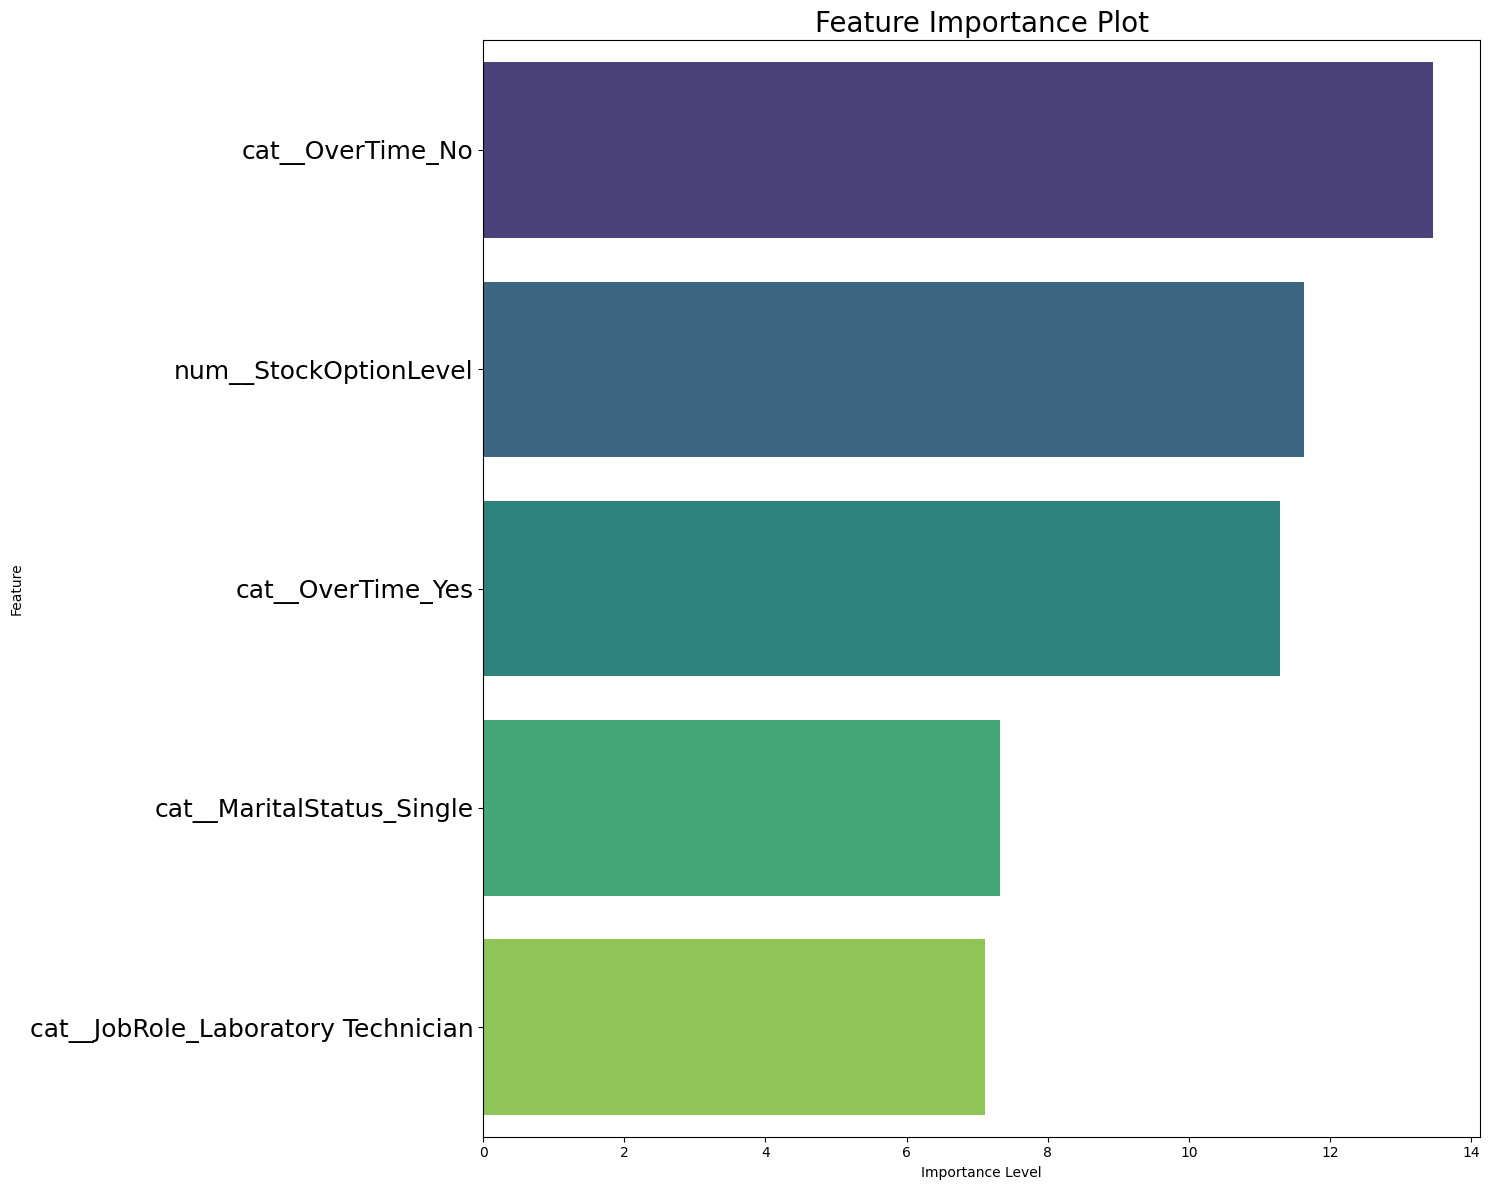

In [39]:
# plot the top 5 feature importance
feature_importance_df = pd.DataFrame(
    {'feature': best_model.named_steps['preprocessing'].get_feature_names_out(),
     'importance': best_model.named_steps['model'].feature_importances_}
).sort_values(by='importance', ascending=False).head()

plt.figure(figsize=(15, 12))
sns.barplot(data=feature_importance_df, 
            x='importance', 
            y='feature',
            palette='viridis')
plt.title('Feature Importance Plot', fontsize=20)
plt.xlabel('Importance Level')
plt.ylabel('Feature')
plt.yticks(fontsize=18)
plt.tight_layout()
plt.show()

## **Shapley Additive Explanations (SHAP)** 

In [40]:
def explain_model(
        model: Any,
        X_test: pd.DataFrame,
        mode: Literal['summary', 'bar', 'both'] = 'both') -> shap.Explanation:
        """
        Generate SHAP-based interpretability visualization for a trained model.
        Automatically handles models inside a pipeline and distinguishes 
        between tree-based and non-tree-based algorithms.

        Parameters
        ----------
        model : Any
                The fitted model or pipeline containing a preprocessor 
                and estimator under 'model' step.
        X_test : pd.DataFrame
                Input feature data used to compute SHAP values.
        mode : {'summary', 'bar', 'both'}, default='both'
                Determines which visualization to display:
                - 'summary' : SHAP summary plot
                - 'bar'     : SHAP feature importance bar plot
                - 'both'    : Shows both summary and bar plots

        Returns
        -------
        shap_values : shap.Explanation
                SHAP values generated for the given model and dataset.    
        """

        # get the preprocessor component only
        preprocessor = model.named_steps['preprocessing']
        # get the estimator component only
        estimator = model.named_steps['model']

        # preprocess X_test
        X_test_transformed = preprocessor.transform(X_test)

        # get feature names after preprocessing
        feature_names = preprocessor.get_feature_names_out()

        # compute SHAP values
        explainer = shap.TreeExplainer(estimator)
        shap_values = explainer(X_test_transformed)

        # visualize SHAP values
        if mode in ['summary', 'both']:
                shap.summary_plot(shap_values, features=X_test_transformed, feature_names=feature_names)
        if mode in ['bar', 'both']:
                shap.summary_plot(shap_values, feature_names=feature_names, plot_type='bar')     

        return shap_values

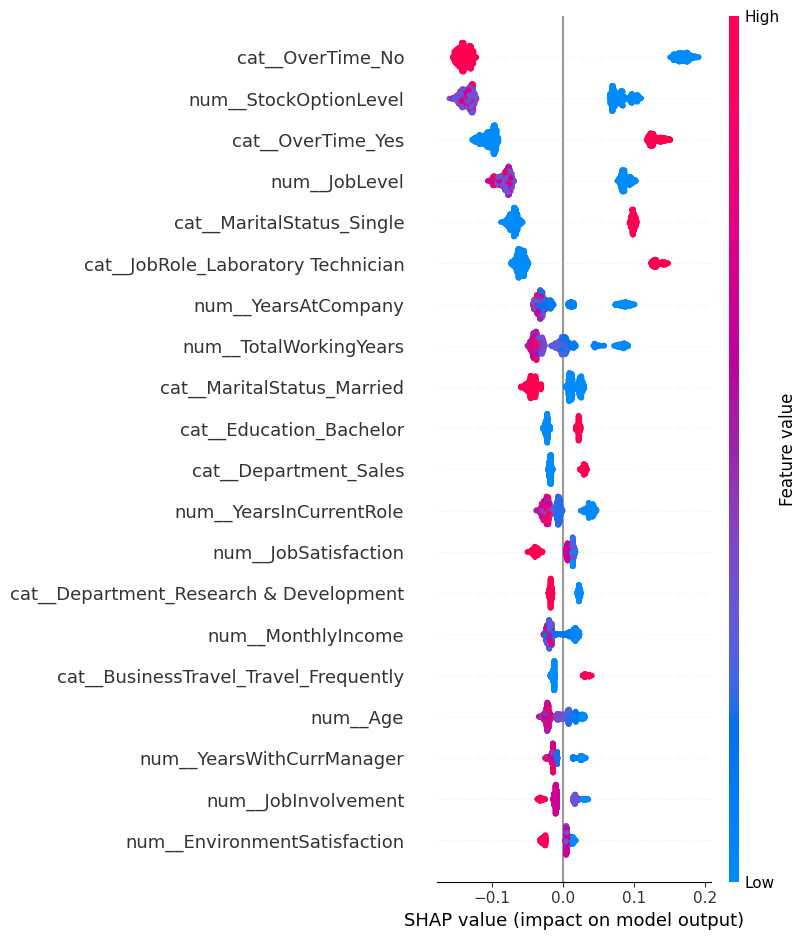

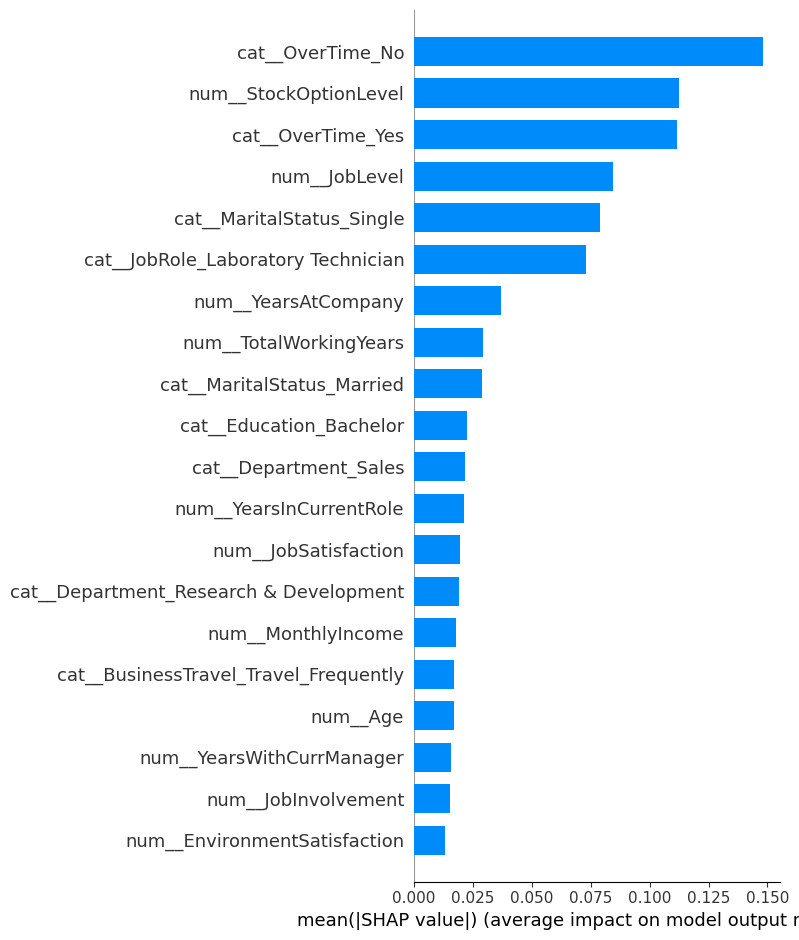

.values =
array([[ 0.0013648 , -0.01388111, -0.00755485, ..., -0.00605625,
        -0.0018132 , -0.00819072],
       [ 0.0013648 , -0.01565288, -0.00990069, ...,  0.04115818,
        -0.00544664,  0.01637355],
       [ 0.0013648 , -0.01191323, -0.00937246, ..., -0.02016147,
        -0.00264259, -0.01387911],
       ...,
       [ 0.0013648 , -0.01273525, -0.00990069, ..., -0.01417614,
        -0.00260096,  0.0161835 ],
       [ 0.00095617, -0.01565288, -0.00957199, ...,  0.03672921,
         0.00579776,  0.02607471],
       [ 0.00270623,  0.03657497,  0.01587846, ...,  0.0367726 ,
        -0.00581554, -0.01075155]], shape=(1176, 55))

.base_values =
array([0.02834685, 0.02834685, 0.02834685, ..., 0.02834685, 0.02834685,
       0.02834685], shape=(1176,))

.data =
array([[ 0.        ,  0.        ,  1.        , ..., -0.62536487,
        -0.36802436, -0.6164065 ],
       [ 0.        ,  0.        ,  1.        , ..., -0.9056351 ,
        -0.05688371, -0.89704685],
       [ 0.        ,  0.   

In [41]:
# generate SHAP visualization plot
shap_values = explain_model(best_model, X_train, mode='both')
shap_values